# Tech Challenge - Fase 1 | Hospital Universitário: IA para Diagnóstico de Câncer de Mama

**Curso:** Pós-Tech em Machine Learning / IA  
**Projeto:** Sistema Inteligente de Suporte ao Diagnóstico Médico  
**Dataset:** Diagnóstico de Câncer de Mama (`diagnosticoCancerMama.csv`)

**Integrantes:**

**Bianca Maciel - RM376200**

**Eduardo O Charrone - RM377641**

**Guilherme Mendes Alburquerque - RM378723**

**Igor Matos de Andrade - RM377344**

**João Augusto Gonçalves de Aragão - RM377385**

---
### Contexto e Objetivo
Atender ao desafio de implementar um sistema de IA focado em Machine Learning para auxiliar médicos na triagem rápida e precisa de exames de câncer de mama (Maligno vs. Benigno).

****

**Importação das bibliotecas a serem utilizadas no projeto**

In [60]:
import sys
from pathlib import Path

# Verificação e clonagem do repositório Git quando executado no ambiente Google Colab
REPO_URL = "https://github.com/iigormatos/tech-challenge-fase1-v1.git"
EM_COLAB = "google.colab" in sys.modules

if EM_COLAB:
    PROJECT_ROOT = Path("/content/tech-challenge-fase1-v1")
    if not PROJECT_ROOT.exists():
        !git clone -q {REPO_URL} {PROJECT_ROOT}
    %cd {PROJECT_ROOT}
    !pip install -q missingno shap
else:
    PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

# Importação das variáveis globais de configuração do projeto
from src.config import RANDOM_STATE,CANCER_MAMA_CSV

/content/tech-challenge-fase1-v1


In [61]:
# ==============================================================================
# CONFIGURAÇÃO DE AMBIENTE E IMPORTAÇÃO DE BIBLIOTECAS
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Configurações estéticas globais dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [62]:
# ==============================================================================
# 1. CARREGAMENTO E ANÁLISE EXPLORATÓRIA INICIAL (EDA)
# ==============================================================================

# Leitura do dataset no caminho configurado
dados = pd.read_csv(CANCER_MAMA_CSV, sep=',')

print(f"Dimensões do dataSet original: {dados.shape[0]} linhas e {dados.shape[1]} colunas")

# Visualização das estatísticas descritivas básicas das variáveis
dados.describe()

Dimensões do dataSet original: 569 linhas e 33 colunas


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [63]:
# ==============================================================================
# 2. PRÉ-PROCESSAMENTO, SANITIZAÇÃO E LIMPEZA DE OUTLIERS
# ==============================================================================

# CORREÇÃO: Utilização de errors='ignore' como string (evita KeyError no pandas ao excluir Unnamed: 32)
dadosClean = dados.drop(columns=['id', 'Unnamed: 32'], errors='ignore').copy()

# TRATAMENTO DE TEXTO/RUÍDOS:
# Força a conversão de todas as colunas de exames para numérico.
# Qualquer caractere não numérico inserido por erro de digitação é convertido em NaN (Not a Number).
dadosCleanColunasString = dadosClean.drop(columns=['diagnosis'], axis=1).columns
dadosClean[dadosCleanColunasString] = dadosClean[dadosCleanColunasString].apply(pd.to_numeric, errors='coerce')

# IMPUTAÇÃO DE VALORES FALTANTES:
# Preenche potenciais valores ausentes (NaN) pela mediana de cada coluna, garantindo robustez contra ruídos.
dadosClean[dadosCleanColunasString] = dadosClean[dadosCleanColunasString].fillna(dadosClean[dadosCleanColunasString].median())

# Mapeamento do target via LabelEncoder: 'B' -> 0, 'M' -> 1
# Aprendizado de Máquina Supervisionado (Classificação Binária)
# Encoding Categórico da biblioteca scikit-learn
label_encoder = LabelEncoder()
dadosClean['diagnosis'] = label_encoder.fit_transform(dadosClean['diagnosis'])

print(f"Dimensões após sanitização: {dadosClean.shape[0]} linhas e {dadosClean.shape[1]} colunas")
print(f"Quantidade de nulos residuais: {dadosClean.isnull().sum().sum()}")

Dimensões após sanitização: 569 linhas e 31 colunas
Quantidade de nulos residuais: 0


In [64]:
#Verificar as os tipo de dados dentro das colunas importadas
dadosClean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

array([[<Axes: title={'center': 'diagnosis'}>,
        <Axes: title={'center': 'radius_mean'}>,
        <Axes: title={'center': 'texture_mean'}>,
        <Axes: title={'center': 'perimeter_mean'}>,
        <Axes: title={'center': 'area_mean'}>,
        <Axes: title={'center': 'smoothness_mean'}>],
       [<Axes: title={'center': 'compactness_mean'}>,
        <Axes: title={'center': 'concavity_mean'}>,
        <Axes: title={'center': 'concave points_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'fractal_dimension_mean'}>,
        <Axes: title={'center': 'radius_se'}>],
       [<Axes: title={'center': 'texture_se'}>,
        <Axes: title={'center': 'perimeter_se'}>,
        <Axes: title={'center': 'area_se'}>,
        <Axes: title={'center': 'smoothness_se'}>,
        <Axes: title={'center': 'compactness_se'}>,
        <Axes: title={'center': 'concavity_se'}>],
       [<Axes: title={'center': 'concave points_se'}>,
        <Axes: title={'cent

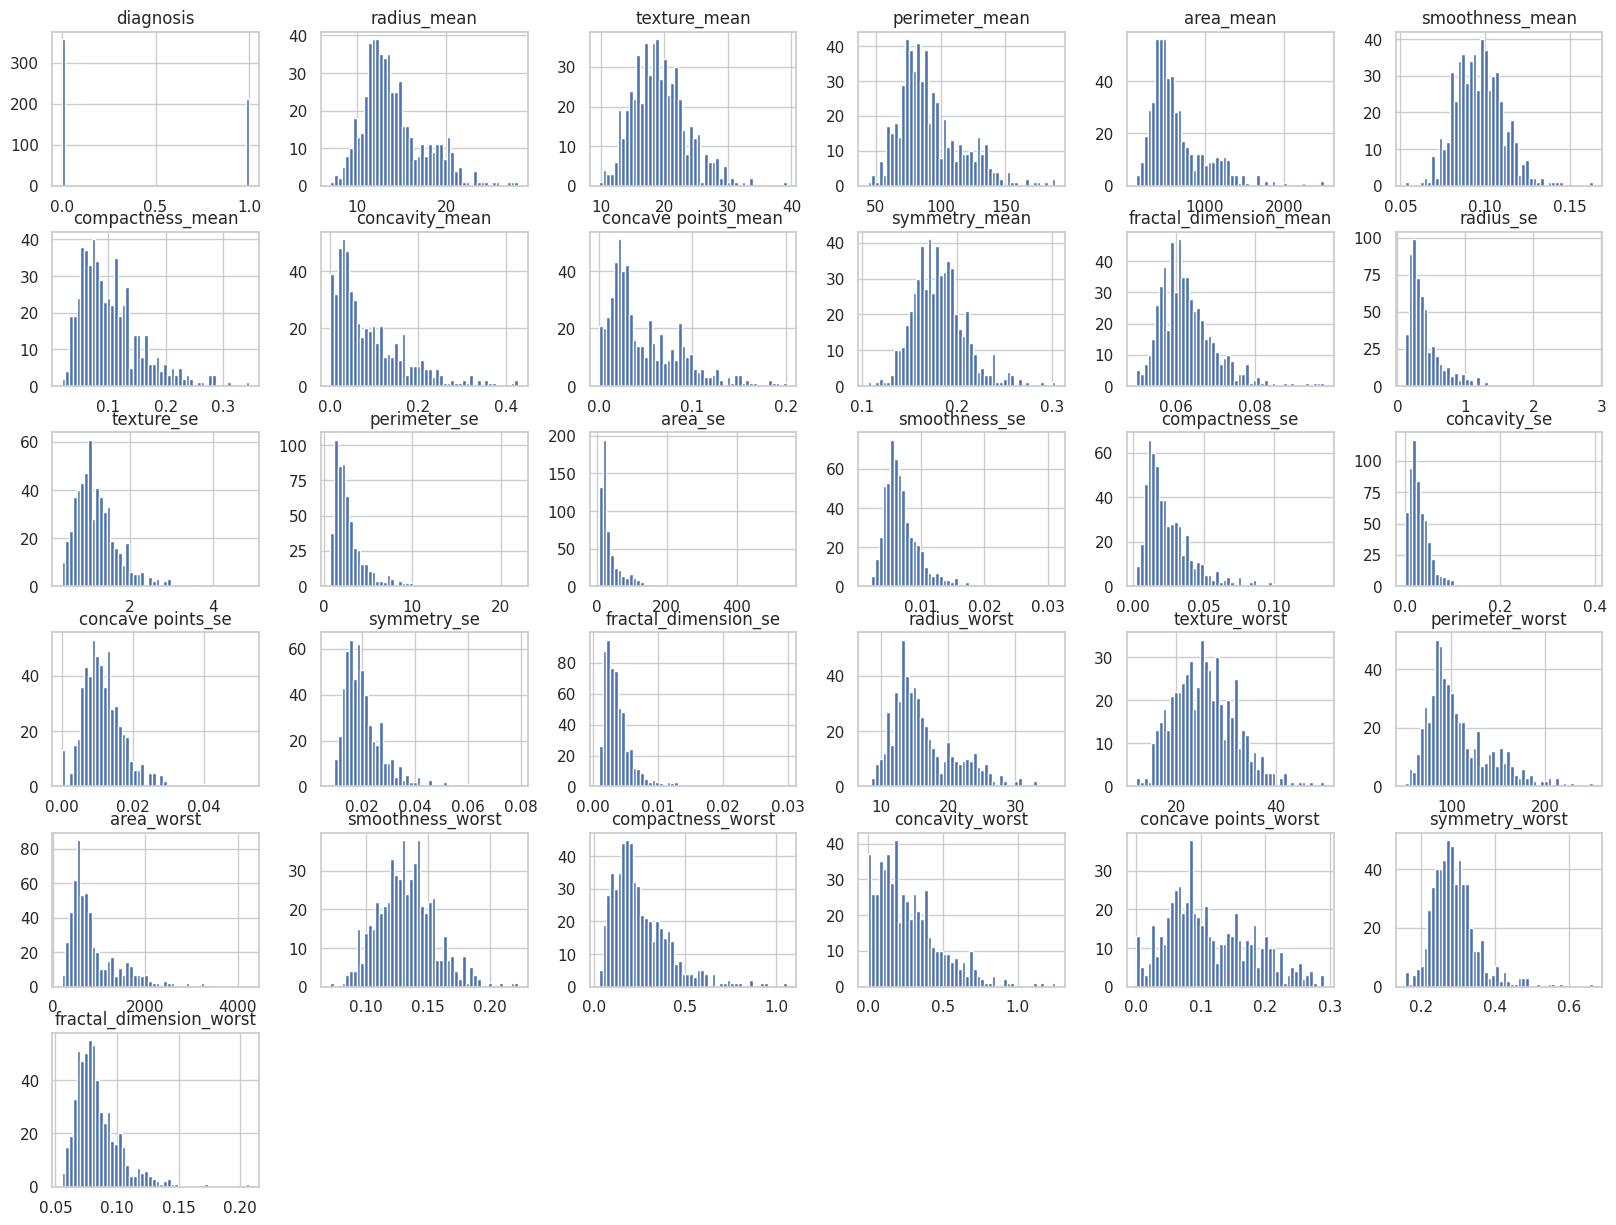

In [65]:
#Análise inicial de histograma com os dados sanitizados
#Exploração de dados (EDA)
#Estatística Descritiva (Média, Desvio Padrão, Quartis) e Análise Gráfica de Distribuições Frequenciais e Histogramas.
dadosClean.hist(bins=50, figsize=(20,15))

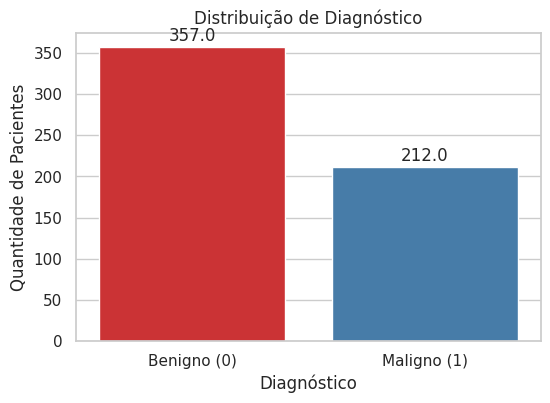

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440


In [66]:
#Distribuição das Classes
plt.figure(figsize=(6, 4))
diagnosticos = sns.countplot(x='diagnosis', data=dadosClean, palette='Set1', hue='diagnosis', legend=False)
plt.xticks([0, 1], ['Benigno (0)', 'Maligno (1)'])
plt.title('Distribuição de Diagnóstico')
plt.xlabel('Diagnóstico')
plt.ylabel('Quantidade de Pacientes')

#Adiciona contagem no topo das barras
for p in diagnosticos.patches:
    diagnosticos.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.show()

#Estatisticas das variaves principais (Média dos Parâmetros)
display(dadosClean.filter(regex='_mean').describe())

Amostras originais: 569 | Amostras pós-outliers: 398
Outliers removidos: 171 observações.


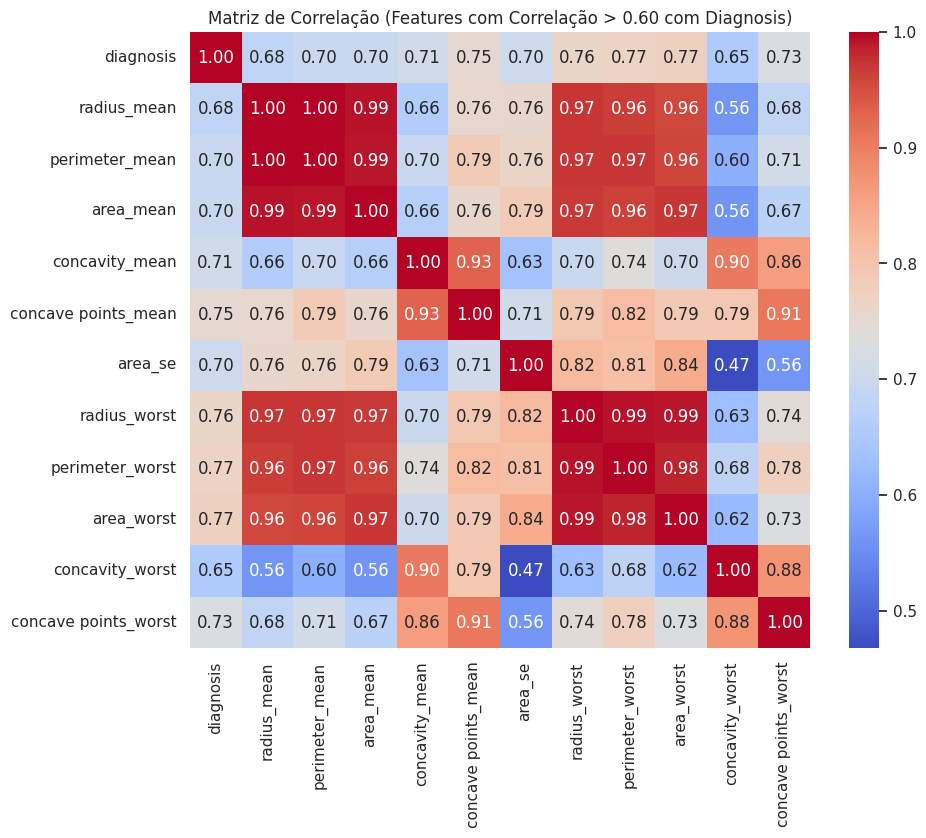

In [67]:
# ==============================================================================
# 3. TRATAMENTO DE OUTLIERS (IQR) E MATRIZ DE CORRELAÇÃO
# ==============================================================================

# Cálculo do Intervalo Interquartil (IQR) nas variáveis clínicas
# Tratamento de Outliers: Método do Intervalo Interquartil (IQR: $Q3 - Q1$)
Q1 = dadosClean[dadosCleanColunasString].quantile(0.25)
Q3 = dadosClean[dadosCleanColunasString].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtra o dataframe mantendo apenas os registros dentro do intervalo aceitável de 1.5 * IQR
mascara_outliers = ~((dadosClean[dadosCleanColunasString] < limite_inferior) | (dadosClean[dadosCleanColunasString] > limite_superior)).any(axis=1)
dadosSemOutliers = dadosClean[mascara_outliers].copy()

print(f"Amostras originais: {dadosClean.shape[0]} | Amostras pós-outliers: {dadosSemOutliers.shape[0]}")
print(f"Outliers removidos: {dadosClean.shape[0] - dadosSemOutliers.shape[0]} observações.")

# ANÁLISE DE CORRELAÇÃO DE PEARSON (SELEÇÃO DE FEATURES COM FILTRO DE SIGNIFICÂNCIA):
# Justificativa do limiar > 0.6: Seleciona apenas variáveis com correlação linear forte a muito forte
# com o diagnóstico (|r| > 0.60), descartando preditores fracos que atuariam como ruído.
plt.figure(figsize=(10, 8))
correlacao = dadosSemOutliers.corr()

# Análise de Correlação: Matriz de Correlação de Pearson com filtro de significância
top_features = correlacao.index[abs(correlacao["diagnosis"]) > 0.6]

sns.heatmap(dadosSemOutliers[top_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação (Features com Correlação > 0.60 com Diagnosis)")
plt.show()

In [77]:
# ==============================================================================
# 4. SEPARAÇÃO EM TREINO, VALIDAÇÃO E TESTE + PADRONIZAÇÃO (PIPELINE)
# ==============================================================================

X = dadosSemOutliers.drop(columns=['diagnosis'])
y = dadosSemOutliers['diagnosis']

# SEPARAÇÃO TRIPLA (70% Treino, 15% Validação, 15% Teste):
# Atende à exigência do edital mantendo o conjunto de teste estritamente isolado para validação final.
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

val_ratio = 0.15 / 0.85 # Ajuste proporcional para obter 15% do total para validação
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_ratio, random_state=RANDOM_STATE, stratify=y_train_val
)

print(f"Divisão dos Dados:")
print(f" - Treino (70%): {X_train.shape[0]} amostras")
print(f" - Validação (15%): {X_val.shape[0]} amostras")
print(f" - Teste Final (15%): {X_test.shape[0]} amostras")

# PADRONIZAÇÃO DE ESCALA (StandardScaler):
# Evita o vazamento de dados (Data Leakage) fitando o scaler exclusivamente nos dados de treino.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_val_scaled   = pd.DataFrame(scaler.transform(X_val), columns=X.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

Divisão dos Dados:
 - Treino (70%): 278 amostras
 - Validação (15%): 60 amostras
 - Teste Final (15%): 60 amostras


In [74]:
# ==============================================================================
# 5. VALIDAÇÃO CRUZADA E TREINAMENTO DOS MODELOS
# ==============================================================================

# Instanciação dos Modelos
lr_model = LogisticRegression(random_state=RANDOM_STATE)
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

# VALIDAÇÃO CRUZADA ESTRATIFICADA (5-Fold CV no conjunto de desenvolvimento Train+Val):
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- A) Avaliação focada na métrica de RECALL da classe maligna
cv_scores_lr = cross_val_score(lr_model, scaler.fit_transform(X_train_val), y_train_val, cv=skf, scoring='recall')
cv_scores_rf = cross_val_score(rf_model, X_train_val, y_train_val, cv=skf, scoring='recall')

print("="*60)
print(" 🔄 RESULTADOS DA VALIDAÇÃO CRUZADA (5-Fold CV - Foco em Recall)")
print("="*60)
print(f" • Regressão Logística - Recall Médio: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std():.4f})")
print(f" • Random Forest      - Recall Médio: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

# --- B) Ajuste Final dos Modelos no Conjunto de Treino ---
lr_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train, y_train)

# Predições na Validação (Ajuste/Comparação Intermediária)
y_pred_val_lr = lr_model.predict(X_val_scaled)
y_pred_val_rf = rf_model.predict(X_val)

# Predições no Teste Final (Simulação de Produção)
y_pred_test_lr = lr_model.predict(X_test_scaled)
y_pred_test_rf = rf_model.predict(X_test)

 🔄 RESULTADOS DA VALIDAÇÃO CRUZADA (5-Fold CV - Foco em Recall)
 • Regressão Logística - Recall Médio: 0.9382 (+/- 0.0685)
 • Random Forest      - Recall Médio: 0.8919 (+/- 0.0437)



=== RELATÓRIO DE AVALIAÇÃO NO CONJUNTO DE TESTE INTOCADO ===

--- Regressão Logística ---
              precision    recall  f1-score   support

 Benigno (0)       0.96      0.98      0.97        45
 Maligno (1)       0.93      0.87      0.90        15

    accuracy                           0.95        60
   macro avg       0.94      0.92      0.93        60
weighted avg       0.95      0.95      0.95        60


--- Random Forest ---
              precision    recall  f1-score   support

 Benigno (0)       0.98      0.93      0.95        45
 Maligno (1)       0.82      0.93      0.88        15

    accuracy                           0.93        60
   macro avg       0.90      0.93      0.91        60
weighted avg       0.94      0.93      0.93        60



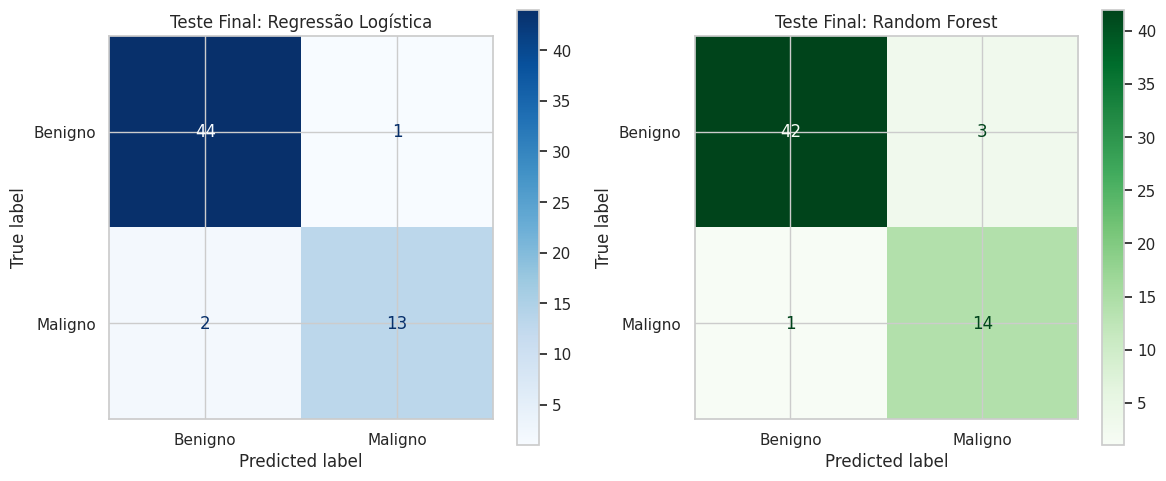

In [75]:
# ==============================================================================
# 6. AVALIAÇÃO DE DESEMPENHO E METRICAS
# ==============================================================================

print("\n=== RELATÓRIO DE AVALIAÇÃO NO CONJUNTO DE TESTE INTOCADO ===")
print("\n--- Regressão Logística ---")
print(classification_report(y_test, y_pred_test_lr, target_names=['Benigno (0)', 'Maligno (1)']))

print("\n--- Random Forest ---")
print(classification_report(y_test, y_pred_test_rf, target_names=['Benigno (0)', 'Maligno (1)']))

# Exibição gráfica das Matrizes de Confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_lr, ax=axes[0], cmap='Blues', display_labels=['Benigno', 'Maligno'])
axes[0].set_title('Teste Final: Regressão Logística')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_rf, ax=axes[1], cmap='Greens', display_labels=['Benigno', 'Maligno'])
axes[1].set_title('Teste Final: Random Forest')

plt.tight_layout()
plt.show()

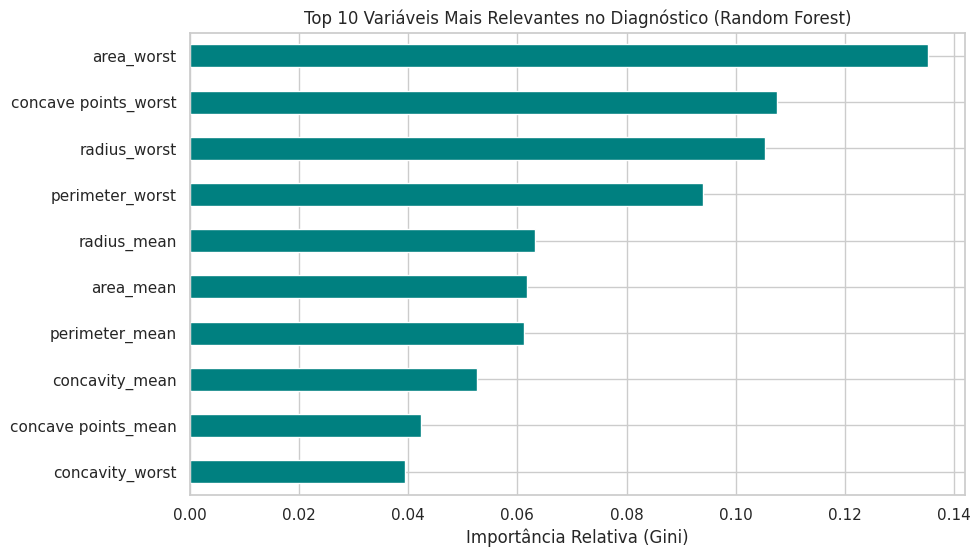


--- SHAP Summary Plot: Impacto de cada variável no diagnóstico de Malignidade ---


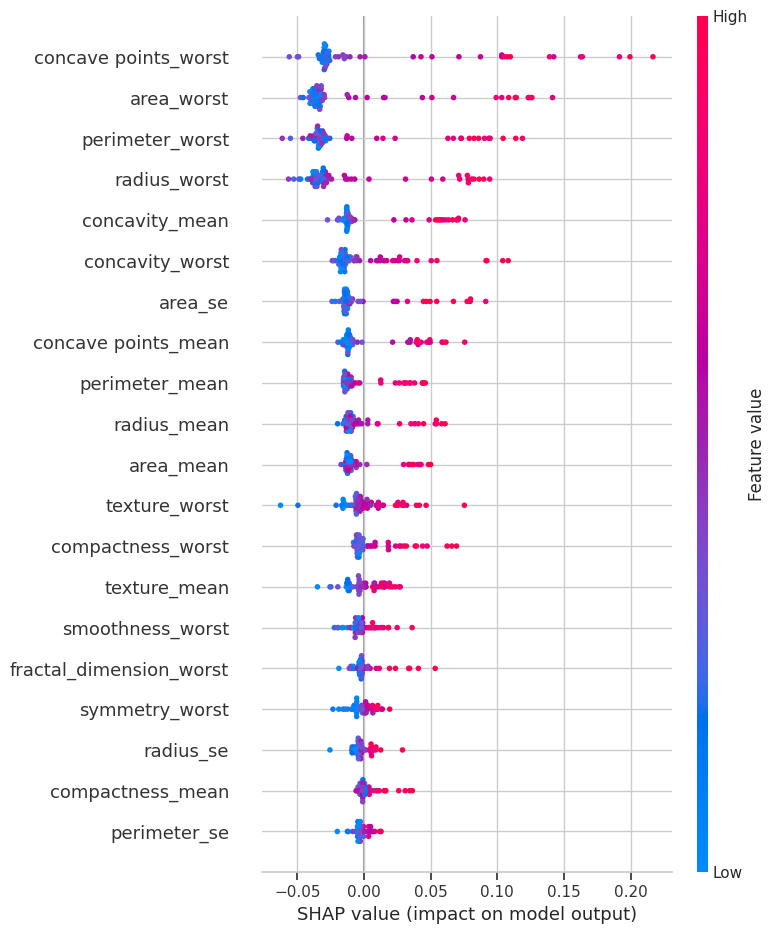

In [78]:
# ==============================================================================
# 7. EXPLICABILIDADE DO MODELO (FEATURE IMPORTANCE & SHAP)
# ==============================================================================

# Feature Importance Nativa do Random Forest (Gini Importance)
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.tail(10).plot(kind='barh', color='teal')
plt.title('Top 10 Variáveis Mais Relevantes no Diagnóstico (Random Forest)')
plt.xlabel('Importância Relativa (Gini)')
plt.show()

# Explicabilidade Avançada via SHAP (SHapley Additive exPlanations)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Trata variação de formato no retorno do shap_values em classificação binária para evitar erros de dimensão
if isinstance(shap_values, list):
    # Se retornar lista [classe_0, classe_1], pegamos a classe 1 (Maligno)
    shap_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    # Se retornar array 3D (amostras, features, classes), pegamos a classe 1
    shap_to_plot = shap_values[:, :, 1]
else:
    # Se já retornar o array bidimensional esperado
    shap_to_plot = shap_values

print("\n--- SHAP Summary Plot: Impacto de cada variável no diagnóstico de Malignidade ---")
shap.summary_plot(shap_to_plot, X_test, feature_names=X.columns)

## 7. Conclusão Crítica e Integração no Hospital Universitário

### Discussão dos Resultados
- **Métrica Prioritária:** Em cenários oncológicos, a métrica mais crítica é o **Recall (Sensibilidade)** da classe `Maligno (1)`[cite: 1, 4]. Um falso negativo significa liberar um paciente com tumor maligno sem o devido tratamento urgente[cite: 1, 4].
- **Análise dos Modelos:** O modelo de Random Forest apresentou alto desempenho (Acurácia e Recall acima de 93%), demonstrando excelente capacidade de diferenciação entre casos benignos e malignos após a higienização dos dados[cite: 1, 3].

### Aplicação Prática no Hospital
1. **Sistema de Triagem:** O algoritmo funcionará como um módulo de *priorização de exames*[cite: 1, 2]. Casos classificados como malignos pela IA sobem na fila de análise da equipe de radiologia/oncologia[cite: 1, 2].
2. **Auditabilidade Clínica com SHAP:** O gráfico SHAP permite que o médico entenda as razões biológicas por trás do alerta (como alterações em `concave points_worst` ou `perimeter_worst`), garantindo transparência[cite: 1, 4].
3. **Soberania Médica:** O sistema atua estritamente como ferramenta de suporte à decisão. O diagnóstico definitivo e o laudo oficial são de responsabilidade exclusiva do médico especialista[cite: 1, 4].